In [5]:
import os as os
import sys
import numpy as np

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")

# adding folders to sys.path
project_root = os.path.abspath(os.path.join(os.getcwd()  , '..', '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

akshat_lisa_root = os.path.abspath(os.path.join(os.getcwd()  , '..',))
if akshat_lisa_root not in sys.path:
    sys.path.insert(0, akshat_lisa_root)

from scripts.readTdi import readTdi, getTdiPath
from scripts.wosa import wosa
from scripts.psdNoise import n_time_noise_from_psd, n_noise_psds, compute_psd_noise_distribution, normalized_psd_residual
from scripts.whitenPsdNoise import n_whitened_time_noises_from_psd, whitened_time_noise_from_psd, n_whiten_noise_psds
from scripts.plot import plot_psd_noise_histogram, plot, plot_orig_and_noise_psds, plot_psd_bias, plot_residual_histogram, plot_median_histogram
from scripts.mle import mle_df
from scripts.medianFuncs import median_exp_pdf
from scripts.plot import plot
from scripts.logpsd import logpsd
import matplotlib.pyplot as plt

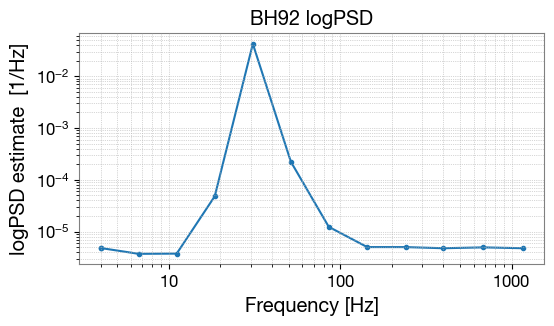

In [6]:
# dummy signal:  30 Hz sine + white noise
fs   = 4096
T    = 8          # seconds
t    = np.arange(0, T, 1/fs)
sig  = np.sin(2*np.pi*30*t) + 0.1*np.random.randn(t.size)

f_log, P_log = logpsd(sig, fs)

plt.figure(figsize=(6,3))
plt.loglog(f_log, P_log, ".-")
plt.xlabel("Frequency [Hz]")
plt.ylabel("logPSD estimate  [1/Hz]")
plt.title("BH92 logPSD")
plt.grid(True, which="both", ls=":")
plt.show()

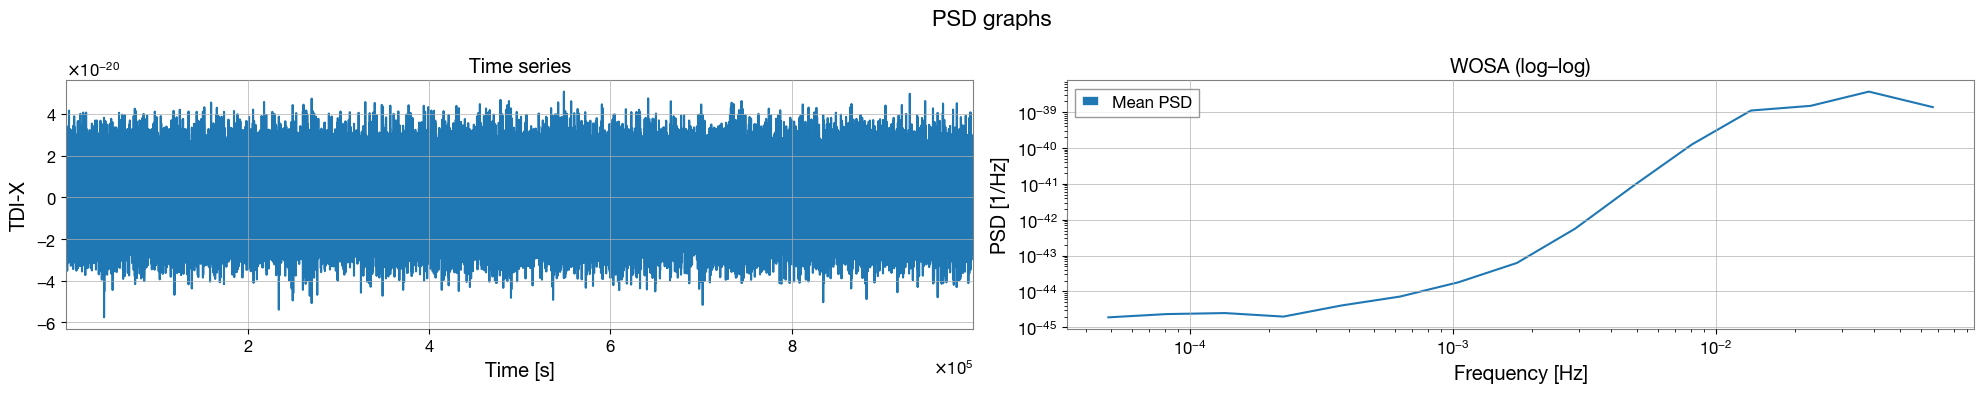

In [10]:
tdi_path = getTdiPath('vsmall_glitch_long_tdi.h5')
data, fs, t = readTdi(tdi_path)
f_log, psd_log = logpsd(x=data, fs=fs, overlap=0)
plot(
    data=data, 
    t=t,
    fs=fs, 
    f=f_log, 
    psd=psd_log, 
    title="TDI-X", 
    bigtitle="PSD graphs"
)

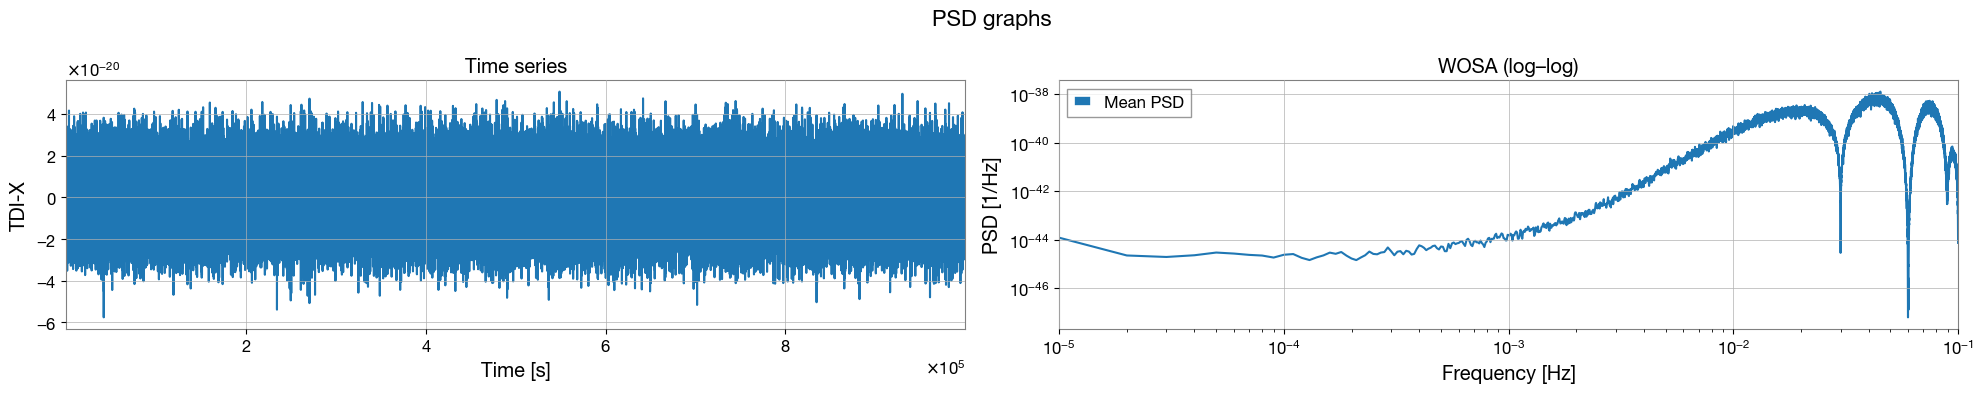

In [8]:
tdi_path = getTdiPath('vsmall_glitch_long_tdi.h5')
data, fs, t = readTdi(tdi_path)
f_wosa, psd_wosa, _, _ = wosa(x=data, fs=fs, nperseg=20000)
plot(
    data=data, 
    t=t,
    fs=fs, 
    f=f_wosa, 
    psd=psd_wosa, 
    nper=20000, 
    title="TDI-X", 
    bigtitle="PSD graphs"
)